In [2]:
import numpy as np
import pandas as pd               
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

sns.set_theme(style="whitegrid")

In [3]:
from sklearn.datasets import load_wine
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['class'] = wine.target
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())


(178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64


In [5]:
# Standardize column names
df.columns = [c.replace(" ", "_") for c in df.columns]


In [6]:
avg_alcohol = np.mean(df['alcohol'])
print("Average Alcohol:", avg_alcohol)

mean_by_class = df.groupby('class')['alcohol'].mean()
print(mean_by_class)


Average Alcohol: 13.00061797752809
class
0    13.744746
1    12.278732
2    13.153750
Name: alcohol, dtype: float64


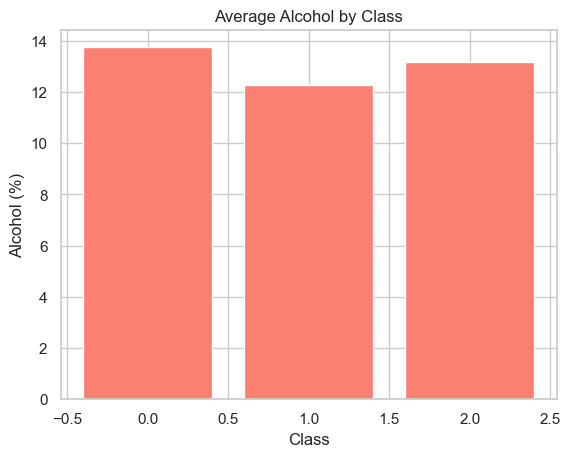

In [7]:
plt.bar(mean_by_class.index, mean_by_class.values, color='salmon')
plt.title("Average Alcohol by Class")
plt.xlabel("Class")
plt.ylabel("Alcohol (%)")
plt.show()


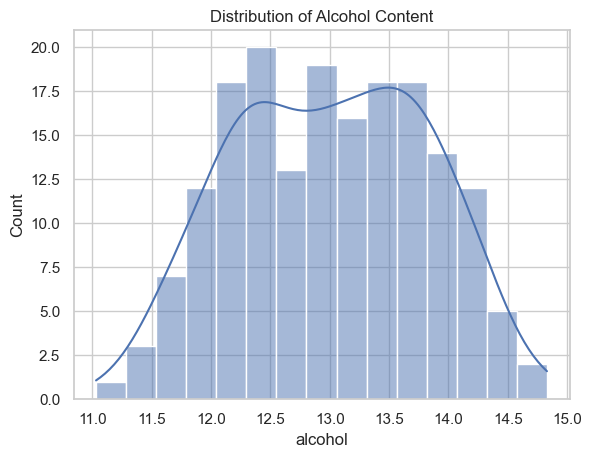

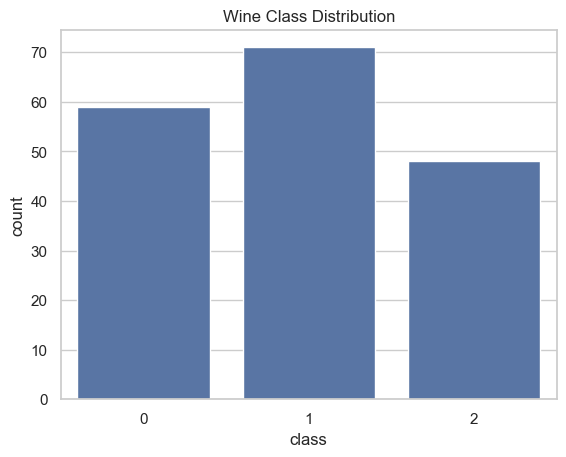

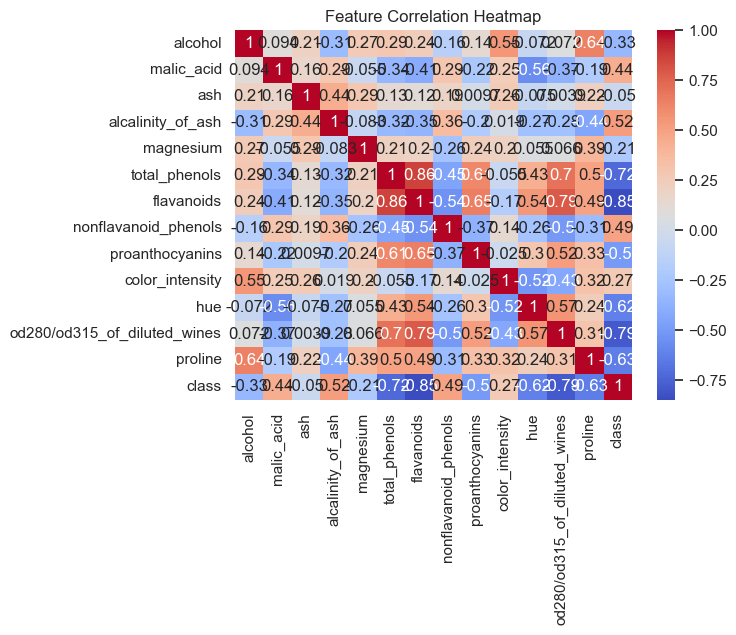

In [8]:
sns.histplot(df['alcohol'], bins=15, kde=True)
plt.title("Distribution of Alcohol Content")
plt.show()

sns.countplot(x='class', data=df)
plt.title("Wine Class Distribution")
plt.show()

sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()
